# fill-comparison metrics — naive LLM vs ordered decomposition

One grouped bar chart per metric (both methods on the same plot, per prop), all linear scale.

- **cost** from `costs_comparison.csv`
- **wall, turns, wall/turn, total tokens, tokens/turn** from `transcript_metrics.csv` (aggregated from the raw `.jsonl` transcripts, not `status.md`).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd()   # run from fill_comparison_study/
costs = pd.read_csv(HERE / 'costs_comparison.csv', dtype={'prop': str})
tm = pd.read_csv(HERE / 'transcript_metrics.csv', dtype={'prop': str})

def _key(p):
    a, b = p.split('.'); return (int(a), int(b))
PROPS = sorted(costs.prop.unique(), key=_key)

cst = costs.set_index('prop')
def piv(col):   # transcript_metrics (long: method in {naive,mine}) -> (naive_arr, mine_arr) over PROPS
    n = tm[tm.method == 'naive'].set_index('prop')[col]
    m = tm[tm.method == 'mine'].set_index('prop')[col]
    return (np.array([n.get(p, np.nan) for p in PROPS], float),
            np.array([m.get(p, np.nan) for p in PROPS], float))

wall_n, wall_m = piv('wall_s')
wpt_n, wpt_m   = piv('wall_per_turn_s')
trn_n, trn_m   = piv('turns')
tok_n, tok_m   = piv('tokens')
tpt_n, tpt_m   = piv('tok_per_turn')

METRICS = [
    dict(title='Cost',            ylabel='cost (USD)',
         naive=np.array([cst.loc[p, 'naive_cost'] for p in PROPS]),
         mine =np.array([cst.loc[p, 'mine_cost']  for p in PROPS]), fmt='${:.0f}'),
    dict(title='Wall time',       ylabel='wall time (min)',   naive=wall_n/60, mine=wall_m/60, fmt='{:.0f}m'),
    dict(title='Turns',           ylabel='turns (API responses)', naive=trn_n, mine=trn_m, fmt='{:.0f}'),
    dict(title='Wall per turn',   ylabel='wall / turn (s)',   naive=wpt_n, mine=wpt_m, fmt='{:.0f}s'),
    dict(title='Total tokens',    ylabel='total tokens (M)',  naive=tok_n/1e6, mine=tok_m/1e6, fmt='{:.0f}M'),
    dict(title='Tokens per turn', ylabel='tokens / turn (k)', naive=tpt_n/1e3, mine=tpt_m/1e3, fmt='{:.0f}k'),
]
print('props:', PROPS)
print('metrics:', [m['title'] for m in METRICS])

props: ['1.1', '1.26', '1.43', '1.47', '3.33']
metrics: ['Cost', 'Wall time', 'Turns', 'Wall per turn', 'Total tokens', 'Tokens per turn']


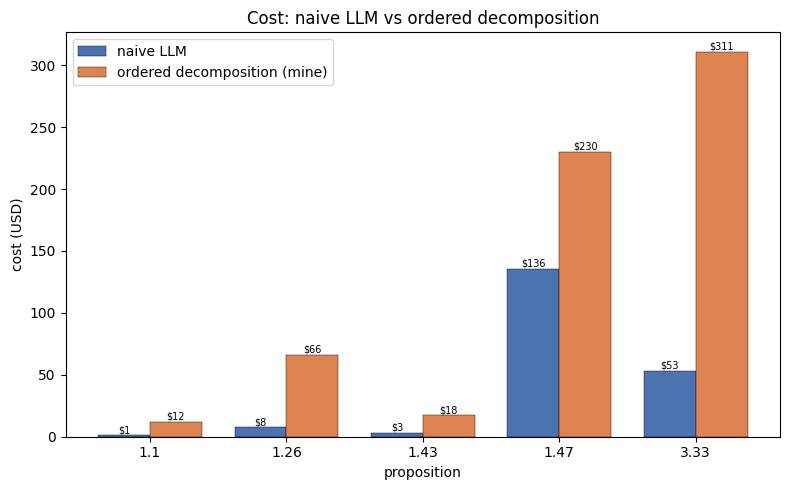

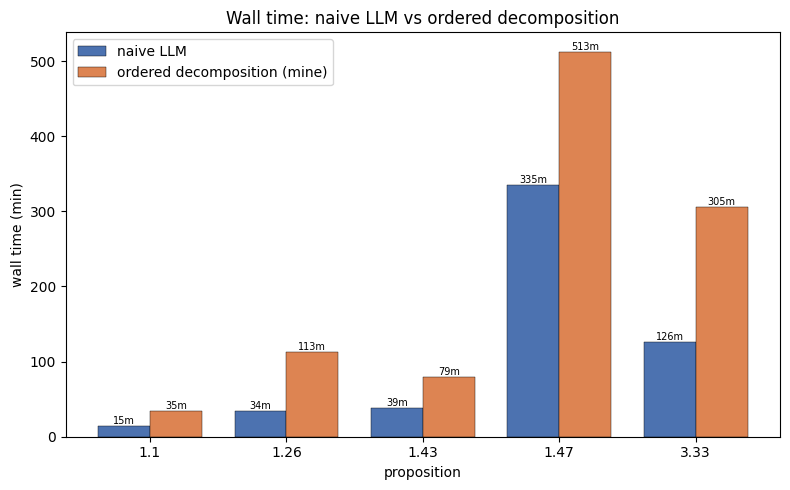

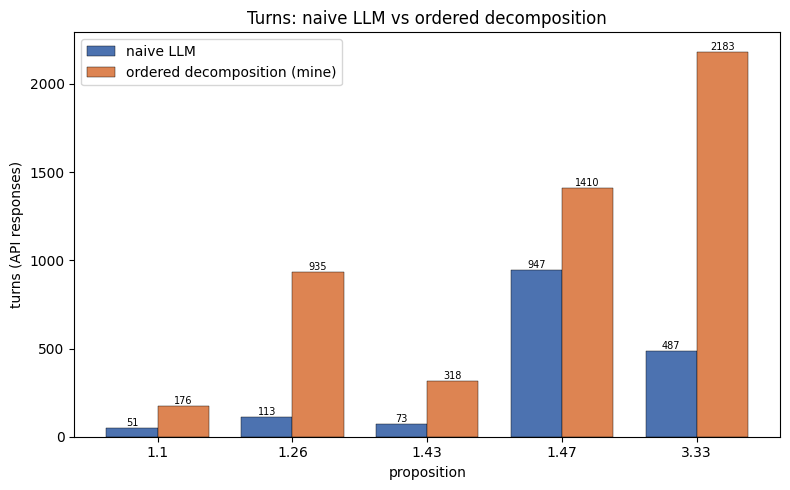

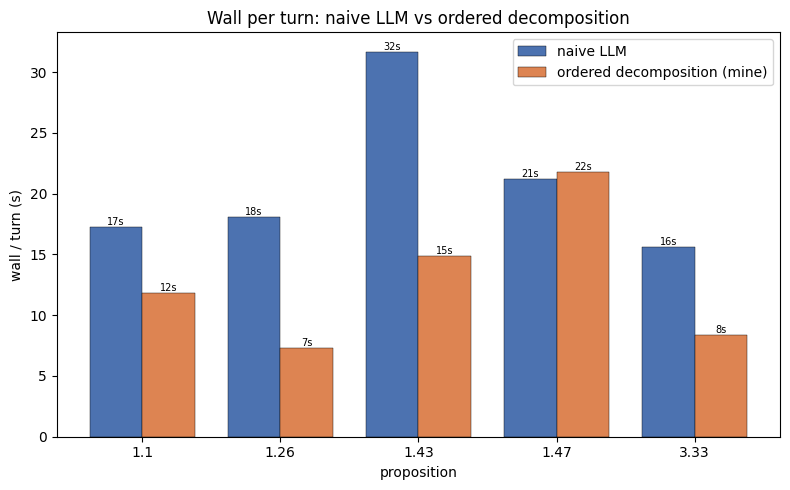

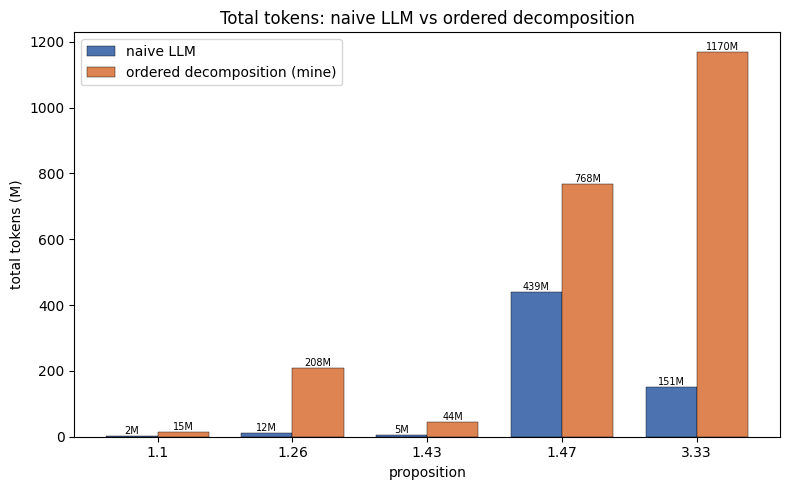

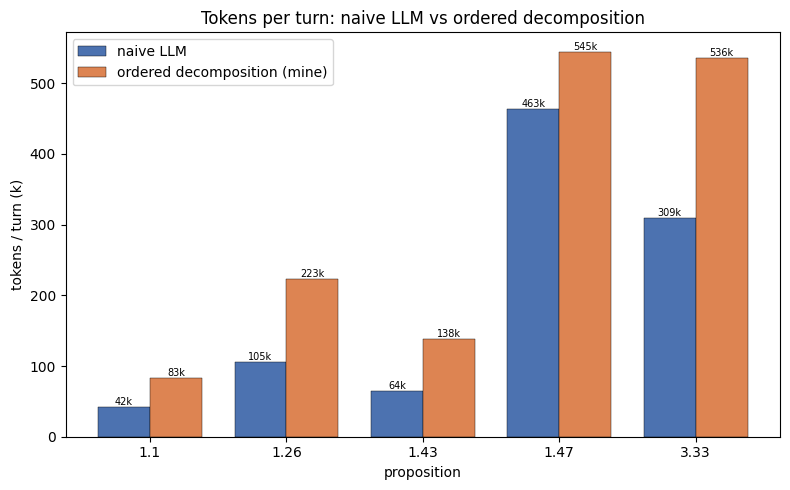

In [2]:
COL = {'naive': '#4C72B0', 'mine': '#DD8452'}
x = np.arange(len(PROPS)); w = 0.38

def grouped_bar(m):
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = []
    bars += ax.bar(x - w/2, m['naive'], w, color=COL['naive'], label='naive LLM',
                   edgecolor='black', linewidth=0.3)
    bars += ax.bar(x + w/2, m['mine'], w, color=COL['mine'], label='ordered decomposition (mine)',
                   edgecolor='black', linewidth=0.3)
    for b in bars:
        h = b.get_height()
        if np.isfinite(h):
            ax.annotate(m['fmt'].format(h), (b.get_x() + b.get_width()/2, h),
                        ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(PROPS)
    ax.set_xlabel('proposition'); ax.set_ylabel(m['ylabel'])
    ax.set_title(f"{m['title']}: naive LLM vs ordered decomposition")
    ax.legend()
    plt.tight_layout(); plt.show()

for m in METRICS:
    grouped_bar(m)